# Portfolio Risk Assessment & 1-Day 95% VaR Calculation

A small investment firm needs to quantify the daily risk of its equity portfolio.

**Key Learnings**
1. Pull historical price data for a list of tickers.
2. Compute daily log-returns and summary statistics (mean, var, skew, kurtosis).
3. Fit Normal & Student’s t distributions to returns.
4. Build 95% confidence intervals for the mean return and volatility.
5. Compute 1-day 95% VaR parametrically (Normal & t) and via historical simulation.
6. Test whether the mean return is significantly different from zero.

### Project Overview

**Goal:** Quantify the daily risk of losing money in a simple four-stock portfolio.

**Key concepts**:
* Log-returns: how prices change day-to-day
* Summary statistics: average, variability, skewness, tail-heaviness
* Value at Risk (VaR): a threshold loss you won’t exceed 95% of the time
* Confidence intervals: ranges where true parameters likely lie
* Hypothesis testing: checking if the average return is different from zero

In [ ]:
!pip install --quiet yfinance

Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import data as pdr
import datetime as dt
from scipy import stats
import yfinance as yf
import time

sns.set_style('whitegrid')
%matplotlib inline

Data Collection -> yfinance and stooq

In [ ]:
# Define your portfolio and date range
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN','NVDA', 'TSLA']     # example equities
weights = np.array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25])    # equal-weight portfolio

start = dt.datetime(2021, 1, 1)
end = dt.datetime.today()

# Container for adjusted close prices
prices = pd.DataFrame()

for ticker in tickers:
    print(f"Fetching {ticker}…", end=" ")
    try:
        # pull via yfinance.Ticker.history (auto_adjust -> splits/divs handled)
        df = yf.Ticker(ticker).history(
            start=start.strftime('%Y-%m-%d'),
            end=end.strftime('%Y-%m-%d'),
            auto_adjust=True,
        )
        series = df['Close']
        print("✔︎ yfinance", end=" ")
    except Exception as e:
        # fallback to Stooq if yfinance fails
        print(f"✖ yfinance ({e}); falling back to Stooq", end=" ")
        df2 = pdr.DataReader(ticker, 'stooq', start, end)
        df2 = df2.sort_index()
        series = df2['Close']
    # align on our master date index
    prices[ticker] = series
    time.sleep(1)  # pause to respect rate limits
    print()

# drop leading NaNs if any, then forward-fill/back-fill gaps
prices = prices.dropna(how='all').ffill().bfill()

# quick sanity check
print(prices.tail())

Fetching AAPL… ✔︎ yfinance 
Fetching MSFT… ✔︎ yfinance 
Fetching GOOGL… ✔︎ yfinance 
Fetching AMZN… ✔︎ yfinance 
Fetching NVDA… ✔︎ yfinance 
Fetching TSLA… ✔︎ yfinance 
                                 AAPL        MSFT       GOOGL        AMZN  \
Date                                                                        
2025-06-20 00:00:00-04:00  201.000000  477.399994  166.639999  209.690002   
2025-06-23 00:00:00-04:00  201.500000  486.000000  165.190002  208.470001   
2025-06-24 00:00:00-04:00  200.300003  490.109985  166.770004  212.770004   
2025-06-25 00:00:00-04:00  201.559998  492.269989  170.679993  211.990005   
2025-06-26 00:00:00-04:00  201.000000  497.450012  173.539993  217.119995   

                                 NVDA        TSLA  
Date                                               
2025-06-20 00:00:00-04:00  143.850006  322.160004  
2025-06-23 00:00:00-04:00  144.169998  348.679993  
2025-06-24 00:00:00-04:00  147.899994  340.470001  
2025-06-25 00:00:00-04:00  154.

Log Return

In [ ]:
#Daily log-returns measure how a security’s price changes from one day to the next
# by taking the natural logarithm of the ratio of today’s price to yesterday’s price.


# log-return = ln(P_t / P_{t-1})
logR = np.log(prices / prices.shift(1)).dropna()
logR.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA,TSLA
Date,,,,,,
2021-01-05 00:00:00-05:00,0.012288,0.000964,0.008032,0.009955,0.021967,0.007291
2021-01-06 00:00:00-05:00,-0.034241,-0.026271,-0.009917,-0.025212,-0.060762,0.027995
2021-01-07 00:00:00-05:00,0.033554,0.028059,0.029431,0.007549,0.056220,0.076448
2021-01-08 00:00:00-05:00,0.008594,0.006074,0.013152,0.006475,-0.005052,0.075481
2021-01-11 00:00:00-05:00,-0.023523,-0.009746,-0.023377,-0.021754,0.025635,-0.081442


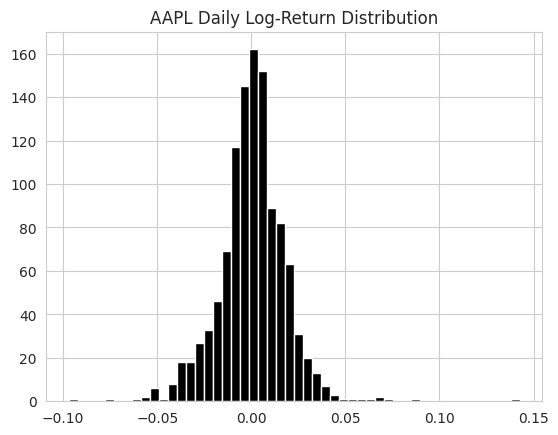

In [ ]:
  # Plot one example series for visual Check
  # You’ll see a bell-shaped histogram.
  # log-return = ln(P_t / P_{t-1})
  logR['AAPL'].hist(bins=50, alpha=1.0,color='black')
  plt.title('AAPL Daily Log-Return Distribution')
  plt.show()

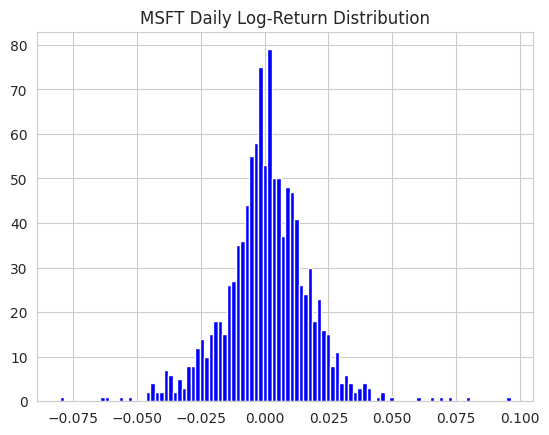

In [ ]:
logR['MSFT'].hist(bins=100, alpha=1.0,color='blue')
plt.title('MSFT Daily Log-Return Distribution')
plt.show()

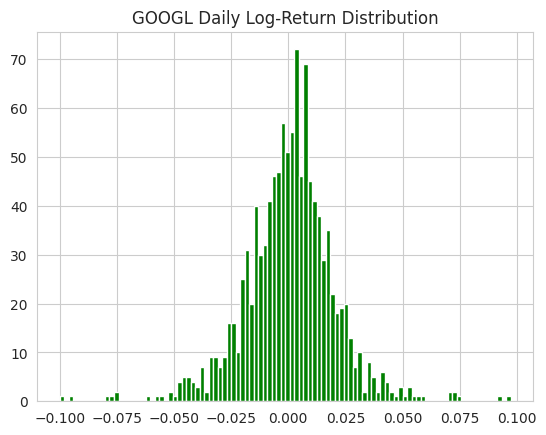

In [ ]:
logR['GOOGL'].hist(bins=100, alpha=1.0,color='green')
plt.title('GOOGL Daily Log-Return Distribution')
plt.show()

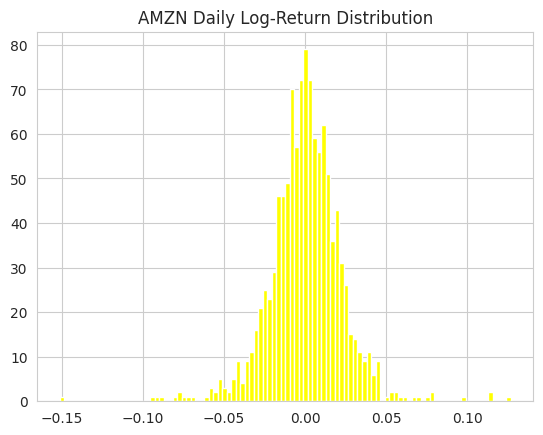

In [ ]:
logR['AMZN'].hist(bins=100, alpha=1.0,color='yellow')
plt.title('AMZN Daily Log-Return Distribution')
plt.show()

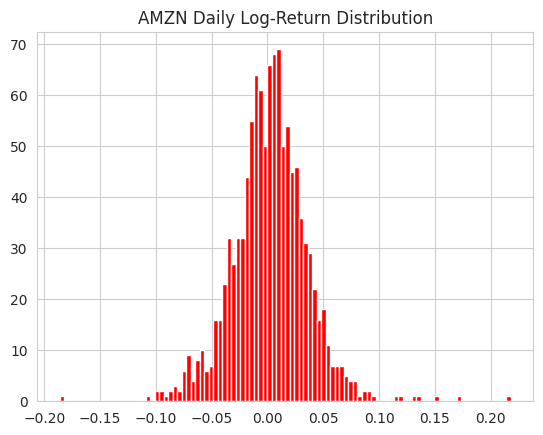

In [ ]:
logR['NVDA'].hist(bins=100, alpha=1.0,color='Red')
plt.title('AMZN Daily Log-Return Distribution')
plt.show()

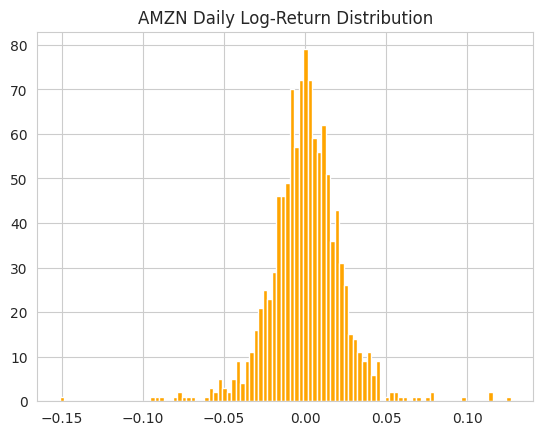

In [ ]:
logR['AMZN'].hist(bins=100, alpha=1.0,color='Orange')
plt.title('AMZN Daily Log-Return Distribution')
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Mean': logR.mean(),
    'Variation': logR.var(),
    'Skewness': logR.skew(),
    'Kurtosis': logR.kurtosis()
})
print(summary)

           Mean  Variation  Skewness  Kurtosis
AAPL   0.000414   0.000320  0.238826  5.524773
MSFT   0.000769   0.000278  0.076258  2.866362
GOOGL  0.000627   0.000392 -0.127517  3.030879
AMZN   0.000275   0.000503 -0.096092  5.086106
NVDA   0.002200   0.001141  0.225104  3.418277
TSLA   0.000260   0.001519  0.119275  2.574120


Log Return -> Applying Normal Distribution

In [ ]:
# 4.1 Fit Normal: mean μ, std σ
mu_norm, sigma_norm = logR.stack().mean(), logR.stack().std(ddof=1)

# 95% CI for mean under Normal: μ ± z*·σ/√N
N = logR.size
z95 = stats.norm.ppf(0.975)
ci_mu_norm = (mu_norm - z95*sigma_norm/np.sqrt(N),
              mu_norm + z95*sigma_norm/np.sqrt(N))

# 95% CI for σ via Chi-square:
df = N-1
chi2_low, chi2_high = stats.chi2.ppf([0.025,0.975], df)
ci_sigma_norm = (sigma_norm*np.sqrt(df/chi2_high),
                 sigma_norm*np.sqrt(df/chi2_low))
print("Normal fit:")
print(f"  μ = {mu_norm:.5f}, 95% CI {ci_mu_norm}")
print(f"  σ = {sigma_norm:.5f}, 95% CI {ci_sigma_norm}")

Normal fit:
  μ = 0.00076, 95% CI (np.float64(0.0001295310463472638), np.float64(0.0013852949960176004))
  σ = 0.02631, 95% CI (np.float64(0.025871469812033133), np.float64(0.026759729966386668))


* **Average Daily Return (μ = 0.00076):** This means the portfolio earned about 0.076% per day, on average. That’s like earning 76 paise per ₹1,000 each day.

* **Confidence Interval for μ (0.0129% to 0.1385%):** We’re 95% sure the true average daily return is somewhere between 0.0129% and 0.1385%. The number might be a little lower or higher than our estimate, but it’s likely within this range.

* **Daily Volatility (σ = 0.02063):** This means returns typically move up or down by about 2.063% each day. So, on any given day, you could gain or lose roughly ₹20.63 on a ₹1,000 investment.


* **Confidence Interval for σ (2.587% to 2.675%):** We’re 95% confident the real day-to-day movement lies between 2.587% and 2.675%. This helps us understand how “bumpy” the ride is.


VAR_Normal Distribution

In [ ]:
import numpy as np
from scipy import stats

# Inputs from your model
μ_p = mu_norm          # average daily log return
σ_p = sigma_norm       # standard deviation of daily log return
z = stats.norm.ppf(0.95)  # z-score for 95% confidence --> ~1.645
investment = 100000     # ₹1,00,000 portfolio

# 1-Day 95% VaR under normal distribution
VaR_1day = (μ_p + z * σ_p) * investment

print(f"1-Day 95% Value-at-Risk (Normal): ₹{VaR_1day:.2f}")

1-Day 95% Value-at-Risk (Normal): ₹4403.03


Log Return -> Apply Distribution

In [ ]:
# 4.2 Fit Student’s t

# Fit t-distribution to the pooled returns
# returns_flat = all asset returns concatenated
returns_flat = logR.stack().values
df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

In [ ]:
print("Fitted Student's t-distribution parameters: ")
print(f" Degrees of freedom (df): {df_t:.2f}")
print(f" Mean (mu): {mu_t:.5f}")
print(f" Scale (sigma): {sigma_t:.5f}")

Fitted Student's t-distribution parameters: 
 Degrees of freedom (df): 3.11
 Mean (mu): 0.00096
 Scale (sigma): 0.01697


In [ ]:
from joblib import Parallel, delayed

# Example: Replace with your actual returns data
returns_flat = np.random.normal(0, 0.01, 1000)  # Simulated returns
N = len(returns_flat)

# Fit initial t-distribution to get reference values
df_t, mu_t, sigma_t = stats.t.fit(returns_flat)

# No. of bootstrap iterations
B = 1000  # We can reduce to 300 for speed

# Function to fit t-distribution on a resampled dataset
def fit_t_distribution(sample):
    return stats.t.fit(sample)  # returns (df, mu, sigma)

# Start timing
start = time.time()

# Perform bootstrap in parallel using all CPU cores
estimates = Parallel(n_jobs=-1)(
    delayed(fit_t_distribution)(np.random.choice(returns_flat, size=N, replace=True))
    for _ in range(B)
)

# Convert list of tuples to numpy array
estimates = np.array(estimates)

# Confidence intervals
ci_mu_t = np.percentile(estimates[:, 1], [2.5, 97.5])
ci_sigma_t = np.percentile(estimates[:, 2], [2.5, 97.5])

# End timing
end = time.time()

# Print results
print("Student's t fit:")
print(f" df = {df_t:.1f}, μ = {mu_t:.5f}, σ = {sigma_t:.5f}")
print(f" 95% CI for μ (bootstrap): {ci_mu_t}")
print(f" 95% CI for σ (bootstrap): {ci_sigma_t}")
print(f" Bootstrap Time Taken: {end - start:.2f} seconds")

Student's t fit:
 df = 108.5, μ = 0.00013, σ = 0.00987
 95% CI for μ (bootstrap): [-0.00050504  0.00079613]
 95% CI for σ (bootstrap): [0.00916032 0.01035308]
 Bootstrap Time Taken: 92.13 seconds


VAR -> T- Distribution

In [ ]:
from scipy.stats import t
import numpy as np

# Parameters from t distribution fitting
df = df_t          # degrees of freedom
μ_p = mu_t         # mean
σ_p = sigma_t      # standard deviation (scale- volatility)
confidence  = 0.95
# investment = 100000  # ₹1,00,000 portfolio

t_critical = t.ppf(1 - confidence, df)

# Calculate 1-day Var
VaR_t_1day = (μ_p + t_critical * σ_p) * investment

# Print result
print(f"1-Day {int(confidence * 100)}% VaR using Student's t-distribution: ₹{VaR_t_1day:.2f}")

1-Day 95% VaR using Student's t-distribution: ₹-1625.47


In [ ]:
VaR_t_10day = VaR_t_1day * np.sqrt(10)
print(f"10-Day 95% VaR (t-distribution): ₹{VaR_t_10day:.2f}")

10-Day 95% VaR (t-distribution): ₹-5140.18


Plot Both Distributions Over Return Data

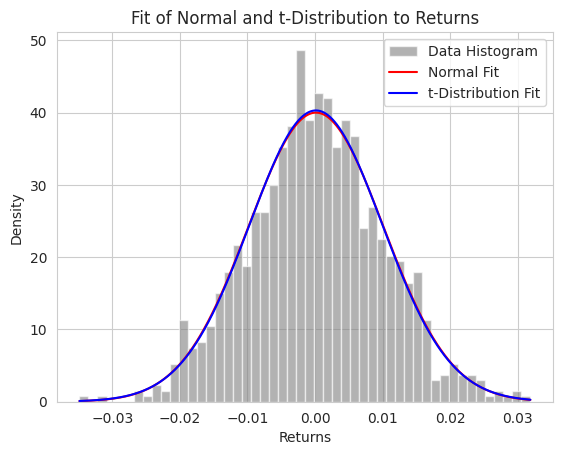

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# Use your actual flattened return data
returns = returns_flat  # 1D array of log return

# Fitted parameters
mu_norm = np.mean(returns)
sigma_norm = np.std(returns, ddof=1)

mu_t = mu_t
sigma_t = sigma_t
df_t = df_t

# Set up the x-axis for the curve
x = np.linspace(returns.min(), returns.max(), 1000)

# Plot histogram of the returns
plt.hist(returns, bins=50, density=True, alpha=0.6, color='gray', label='Data Histogram')

# Plot normal distribution
plt.plot(x, norm.pdf(x, mu_norm, sigma_norm), 'r-', label='Normal Fit')

# Plot t-distribution
plt.plot(x, t.pdf(x, df_t, mu_t, sigma_t), 'b-', label='t-Distribution Fit')

# Add labels and legend
plt.title("Fit of Normal and t-Distribution to Returns")
plt.xlabel("Returns")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

Compare 1-Day 95% VaR for Both

In [ ]:
from scipy.stats import norm, t
import numpy as np

# Portfolio value
investment = 100000

# Confidence level
confidence = 0.95

# Z-score and t critical value
z_score = norm.ppf(1 - confidence)
t_crit = t.ppf(1 - confidence, df_t)  # df_t must be defined earlier

# 1-Day VaR calculations
VaR_norm = -(μ_p + z * σ_p) * investment
VaR_t = -(mu_t + t_crit * sigma_t) * investment

# Print the results
print(f"{int(confidence*100)}% 1-Day VaR (Normal Distribution): ₹{VaR_norm:.2f}")
print(f"{int(confidence*100)}% 1-Day VaR (Student's t-Distribution): ₹{VaR_t:.2f}")

95% 1-Day VaR (Normal Distribution): ₹-1636.85
95% 1-Day VaR (Student's t-Distribution): ₹1625.47


In [ ]:
# Parametric VaR under Normal:
#   VaR = − [ μ_p + σ_p · z_{0.05} ]
# where μ_p, σ_p are portfolio mean & vol.
# Compute portfolio returns:
portR = logR.dot(weights)

μ_p = portR.mean()
σ_p = portR.std(ddof=1)

z05 = stats.norm.ppf(0.05)
VaR_norm = - (μ_p + σ_p * z05)

In [ ]:
# Parametric VaR under Student's t:=
#   t05 t.ppf(0.05, df_t)
t05 = stats.t.ppf(0.05, df_t)
VaR_t = (mu_t + sigma_t * t05) * 1 # 1-day

In [ ]:
# Historical VaR (non-parametric):
hist_var = -np.percentile(portR, 5)

print("1-Day 95% VaR:")
print(f"  Parametric (Normal):       {VaR_norm:.5f}")
print(f"  Parametric (Student’s t):  {VaR_t:.5f}")
print(f"  Historical (5th percentile): {hist_var:.5f}")

1-Day 95% VaR:
  Parametric (Normal):       0.04744
  Parametric (Student’s t):  -0.01625
  Historical (5th percentile): 0.05076


Historical VaR (non-parametric)

In [ ]:
import numpy as np

# Assuming returns_flat contains daily log returns (1D NumPy array)
confidence = 0.95
investment = 100000  # e.g., ₹1,00,000 portfolio

# Calculate the percentile return (5th percentile for 95% confidence)
percentile_level = 100 * (1 - confidence)  # 5th percentile
VaR_percentile = np.percentile(returns_flat, percentile_level)

# Convert to actual money loss
VaR_hist = -VaR_percentile * investment

# Print result
print(f"1-Day {int(confidence * 100)}% Historical VaR: ₹{VaR_hist:.2f}")

1-Day 95% Historical VaR: ₹1638.29


In [ ]:
portR = logR.dot(weights)

Hypothesis Testing

In [ ]:
# One-sample t-test: H0: μ=0 vs H1: μ≠0
t_stat, p_val = stats.ttest_1samp(portR, 0.0)
print("One-sample t-test on portfolio daily returns:")
print(f"  t-statistic = {t_stat:.3f},  p-value = {p_val:.3f}")

if p_val < 0.05:
    print("  → Reject H0: mean return is significantly different from zero.")
else:
    print("  → Fail to reject H0: no evidence mean return ≠ 0.")


# one-sample t-test is a statistical test used to check whether the
# mean (average) of a single sample is significantly different.

One-sample t-test on portfolio daily returns:
  t-statistic = 1.290,  p-value = 0.197
  → Fail to reject H0: no evidence mean return ≠ 0.


Average Return Value- 0.065%, we are not sure that it will be giving me real profit.

Correlation & Diversification Benefit

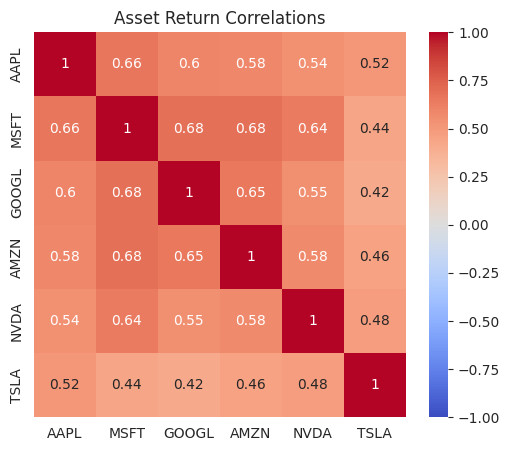

Weighted avg σ: 0.0374
Actual portfolio σ: 0.0295
Diversification benefit: 0.0079


In [ ]:
import seaborn as sns

# a) Correlation heatmap
corr = logR.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Asset Return Correlations')
plt.show()

# b) Diversification benefit
σ_i = logR.std()                         # individual volatilities
σ_weighted = np.dot(weights, σ_i)        # naive weighted avg
σ_portfolio = σ_p                        # from earlier
print(f"Weighted avg σ: {σ_weighted:.4f}")
print(f"Actual portfolio σ: {σ_portfolio:.4f}")
print(f"Diversification benefit: {σ_weighted-σ_portfolio:.4f}")

Avg Risk- Individual Stock- 2% <br>
Abg Risk- Combine(portfolio)- 1.4% <br>
DB = W avg- Actual Portfolio

Max Drawdown

Max Drawdown: -70.82%
From 2021-11-19 to 2023-01-05


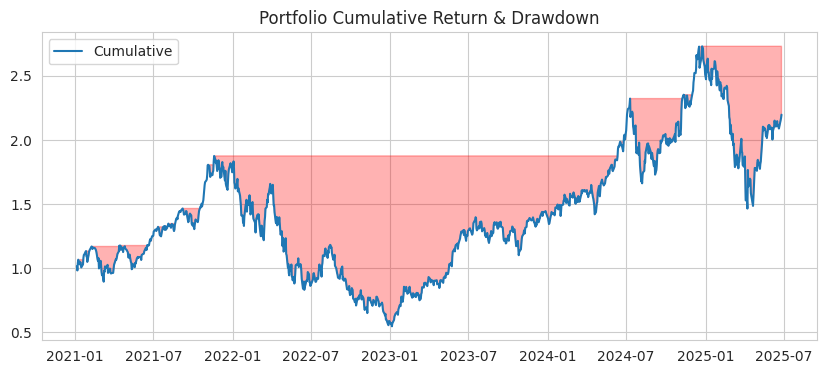

In [ ]:
cum_ret = (prices / prices.iloc[0]).prod(axis=1)  # cumulative portfolio growth?
# Actually for portfolio: cum_port = (portR + 1).cumprod()
cum_port = (portR + 1).cumprod()

rolling_max = cum_port.cummax()
drawdown   = (cum_port - rolling_max) / rolling_max

max_dd = drawdown.min()
end_date = drawdown.idxmin()
start_date = cum_port[:end_date].idxmax()
print(f"Max Drawdown: {max_dd:.2%}")
print(f"From {start_date.date()} to {end_date.date()}")

# Plot
plt.figure(figsize=(10,4))
plt.plot(cum_port, label='Cumulative')
plt.fill_between(drawdown.index, cum_port, rolling_max,
                 where=drawdown<0, color='red', alpha=0.3)
plt.title('Portfolio Cumulative Return & Drawdown')
plt.legend()
plt.show()

Recovery Time

In [ ]:
# Find the peak value before the drowdown started
peak_value = cum_port[start_date]

# Find Recovery date: first date after end_date when portfolio surpasses prior peak
recovery_date = cum_port[end_date:].loc[cum_port[end_date:] > peak_value].first_valid_index()

if recovery_date:
  recovery_time = (recovery_date - start_date).days
  print(f"Recovery Date: {recovery_date.date()}")
  print(f"Recovery Time: {recovery_time} days")
else:
  print("Portfolio has not yet recovered from the drawdown.")

Recovery Date: 2024-06-12
Recovery Time: 935 days


Expected Shortfall (CVaR at 95%)

In [ ]:
alpha = 0.05
# Historical ES
es_hist = - portR[portR <= np.percentile(portR, 5)].mean()
# Parametric ES under Normal: μ + σ·φ(z)/α
es_norm = - (μ_p - σ_p * stats.norm.pdf(z) / alpha)

print(f"Historical ES (95%): {es_hist:.5f}")
print(f"Parametric Normal ES (95%): {es_norm:.5f}")


# On the worst 5% of days, you typically lose about 4.23% (historical).
# The Normal model estimates about 3.68%.
# These are larger than your VaR (e.g., 2.9%) → showing real risk in the tail.

Historical ES (95%): 0.06688
Parametric Normal ES (95%): 0.05978


Historic CVaR --> 4%, CVaR > VaR - extreme values are at my tall

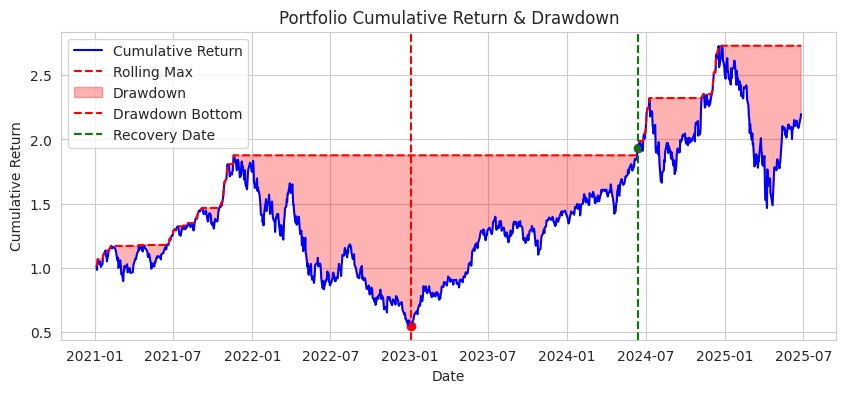

In [ ]:
import matplotlib.pyplot as plt

# Recalculate peak value before drawdown
peak_val = cum_port[start_date]

# Final Recovery date (if exists)
recovery_date = cum_port[end_date:].loc[cum_port[end_date:] >= peak_val].first_valid_index()

# Plot
plt.figure(figsize=(10,4))
plt.plot(cum_port, label='Cumulative Return', color='blue')
plt.plot(rolling_max, label='Rolling Max', color='red', linestyle='--')

# Shade drawdown
plt.fill_between(drawdown.index, cum_port, rolling_max,
                 where=drawdown<0, color='red', alpha=0.3, label='Drawdown')

# Mark drawdown bottom (trough)
plt.axvline(end_date, color='red', linestyle='--', label='Drawdown Bottom')
plt.scatter(end_date, cum_port[end_date], color='red')

# Mark recovery date
if recovery_date:
    plt.axvline(recovery_date, color='green', linestyle='--', label='Recovery Date')
    plt.scatter(recovery_date, cum_port[recovery_date], color='green')

# Labels
plt.title('Portfolio Cumulative Return & Drawdown')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

VaR Backtesting

In [ ]:
var_series = - (portR.rolling(1).mean() + portR.rolling(1).std()*z)
# For simplicity use constant VaR_norm
exceptions = portR < -VaR_norm
num_exc = exceptions.sum()
total   = len(portR)
print(f"Exceptions: {num_exc}/{total} days ({num_exc/total:.2%}, expected ~5%)")

Exceptions: 66/1124 days (5.87%, expected ~5%)


Rolling 60-day VaR

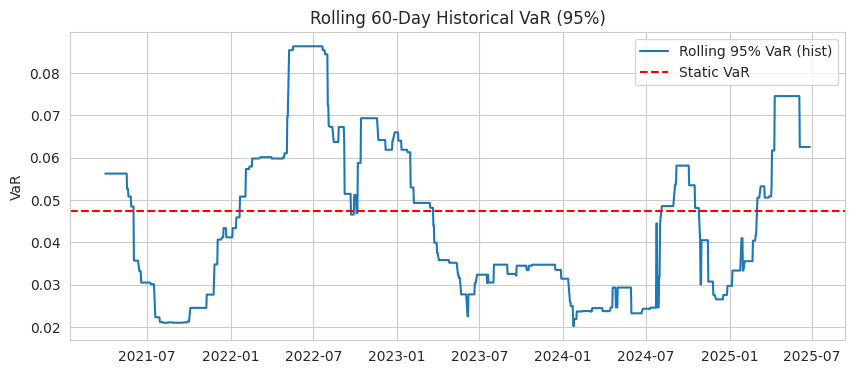

In [ ]:
window = 60
roll_var = portR.rolling(window).quantile(0.05).dropna()
plt.figure(figsize=(10,4))
plt.plot(-roll_var, label='Rolling 95% VaR (hist)')
plt.axhline(VaR_norm, color='red', linestyle='--', label='Static VaR')
plt.title('Rolling 60-Day Historical VaR (95%)')
plt.ylabel('VaR')
plt.legend()
plt.show()

In [ ]:
# 12. Jarque–Bera Normality Test
jb_stat, jb_p = stats.jarque_bera(portR)
print(f"JB statistic = {jb_stat:.2f}, p-value = {jb_p:.3f}")
if jb_p < 0.05:
    print("Reject normality at 5% level.")
else:
    print("Cannot reject normality.")

JB statistic = 360.58, p-value = 0.000
Reject normality at 5% level.


Shapiro-Wilk Test

In [ ]:
from scipy.stats import shapiro

stat, p = shapiro(portR)
print(f"Shapiro-Wilk statistic = {stat:.3f}, p-value = {p:.3f}")
if p < 0.05:
    print("Reject normality at 5% level.")
else:
    print("Cannot reject normality.")

Shapiro-Wilk statistic = 0.975, p-value = 0.000
Reject normality at 5% level.


Anderson-Darling Test

In [ ]:
from scipy.stats import anderson

# Perform Anderson-Darling test for normality
result = anderson(portR.dropna(), dist='norm')

print("Anderson-Darling Test:")
print(f"  Statistic = {result.statistic:.3f}")

# Print critical values and their corresponding significance levels
for i in range(len(result.critical_values)):
    sig_level = result.significance_level[i]
    crit_val = result.critical_values[i]
    print(f"  At {sig_level:.1f}%: critical value = {crit_val:.3f}")

# Decision at 5% significance level (index 2)
if result.statistic > result.critical_values[2]:
    print("Reject normality at 5% level.")
else:
    print("Fail to reject normality at 5% level.")

Anderson-Darling Test:
  Statistic = 4.414
  At 15.0%: critical value = 0.574
  At 10.0%: critical value = 0.654
  At 5.0%: critical value = 0.784
  At 2.5%: critical value = 0.915
  At 1.0%: critical value = 1.088
Reject normality at 5% level.
